In [29]:
import sys 
import os 
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from analysis_of_simulation_result import * 
from fitting import sigmoid,hill
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [30]:
REPO_ROOT

PosixPath('/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release')

In [32]:
params_opt_labial = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/labial/result_av1a1_170.pkl','rb'))

V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x


firing = [*[(np.round(hill(c,V_l1l2,K_l1l2,n_l1l2),1),np.round(hill(c,V_l3,K_l3,n_l3),1)) for c in [10,50,100,500]]]



popt = [k_act_L,r0_L,h_L]

In [16]:
data_df_all_labial_per_percent = pd.read_parquet('data/Labial_suc_data.parquet')
data_df_geosmin_labial_per_percent = pd.read_parquet('data/Labial_suc_geo_data.parquet')
sem_df_all_labial_per_percent = pd.read_parquet('data/Labial_suc_data_sem.parquet')
sem_df_geosmin_labial_per_percent = pd.read_parquet('data/Labial_suc_geo_data_sem.parquet')


# reduction_df_tarsal = pd.read_parquet('/volume_4/research/seongbong/flywire/geosmin_project/figure/figure8/Delete_edges_wo_considering_disinhibition_hm_thresholded_0.1_0.2/tarsal/weight_order/simulation/reduction_rate_all_tarsal.parquet')

mn9_ff_suc_tarsal = pd.read_parquet('data/Tarsal_suc_data.parquet')
mn9_ff_suc_geo_tarsal = pd.read_parquet('data/Tarsal_suc_geo_data.parquet')
reduction_rate_tarsal = mn9_ff_suc_geo_tarsal.loc['0.0%'].values[0]/mn9_ff_suc_tarsal.loc['0.0%'].values[0]
# reduction_rate_tarsal
reduction_rate_per_concent = dict(zip([10,50,100,500],reduction_rate_tarsal))
reduction_rate_per_concent

{10: 0.3019607843137255,
 50: 0.430784123910939,
 100: 0.46609508963367113,
 500: 0.5050925925925925}

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

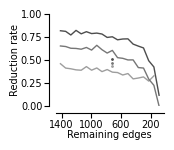

In [17]:
suc_data_per_percent = data_df_all_labial_per_percent#pd.concat(list(data_df_all_labial_per_percent.values()))
suc_data_per_percent.index = [f'{np.round(x*100,1)}%' for x in np.round(np.arange(0,1,0.05),3)]
suc_std_per_percent = sem_df_all_labial_per_percent#pd.concat(list(sem_df_all_labial_per_percent.values()))
suc_std_per_percent.index = [f'{np.round(x*100,1)}%' for x in np.round(np.arange(0,1,0.05),3)]

suc_geo_data_per_percent = data_df_geosmin_labial_per_percent#pd.concat(list(data_df_geosmin_labial_per_percent.values()))
suc_geo_data_per_percent.index = [f'{np.round(x*100,1)}%' for x in np.round(np.arange(0,1,0.05),3)]
suc_geo_std_per_percent = sem_df_geosmin_labial_per_percent#pd.concat(list(sem_df_geosmin_labial_per_percent.values()))
suc_geo_std_per_percent.index = [f'{np.round(x*100,1)}%' for x in np.round(np.arange(0,1,0.05),3)]



LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32      # 45도 xtick 기준으로 통일


fontsize = 7
fig,ax = plt.subplots(1,1,figsize=(1.4,1.2))


cmap = {1:'#9E9E9E',2:'#767676',3:'#4D4D4D'}
num_iter = 1 
for ff1,ff2 in firing[1:]:
    reduction_df = suc_geo_data_per_percent[f'{ff1}Hz_{ff2}Hz_170Hz']/suc_data_per_percent[f'{ff1}Hz_{ff2}Hz_0Hz']

    reduction_df.plot(ax=ax,color=cmap[num_iter],lw=1)#
    num_iter += 1 

ax.set_ylim([0,1])
ax.set_ylabel('Reduction rate')
ax.set_xlabel('Remaining edges')
ax.spines[['top','right']].set_visible(False)


legend_elements = [
    Line2D([0], [0], color='#9E9E9E', lw=2, label='60Hz'),
    Line2D([0], [0], color='#767676', lw=2, label='40Hz'),
    Line2D([0], [0], color='#4D4D4D', lw=2, label='20Hz'),
#     Line2D([0], [0], color='red', lw=2, label='Tarsal intact (90Hz)'),
]

ax.spines[['top','right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward',5)
)

ax.tick_params(pad=1)

# fig.subplots_adjust(
#     left=LEFT,
#     right=RIGHT,
#     top=TOP,
#     bottom=BOTTOM
# )

for num_iter,concent in enumerate([50,100,500]):
    ax.scatter(9.986,reduction_rate_per_concent[concent],color=cmap[num_iter+1],s=1)


ax.set_xticks(
    [0.214, 5.929, 11.643, 17.357],
    [1400, 1000, 600, 200]
)
# ax.set_xlim([0,2])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)

# plt.savefig('reduction_rate_vs_remaining_edges.svg')